### Calculo de la magntiud asboluta, reducida y observada de asteroides usando sus elementos orbitales y asumiento propiedades fisicas

$$
H(\alpha) = V(r, \Delta, \alpha) - 5 \log(r \Delta)
$$

$$
H(\alpha) = H -2.5\log{[(1-G)\phi_1(\alpha) + G\phi_2(\alpha)]}
$$

$$
V(r, \Delta, \alpha) = H - 2.5\log{[(1-G)\phi_1(\alpha) + G\phi_2(\alpha)]} + 5 \log(r \Delta)
$$

Asumumos G = 0.15, donde

$$
\phi_n(\alpha) = W\phi_{ns} + (1 - W)\phi_{nl}
$$

$$
W = exp(-90.56\tan^2{(\alpha/2)})
$$

Y $\phi_{ns}$, $\phi_{nl}$ siguen las siguientes expresiones 

$$
\phi_{ns} = 1 - \frac{C_n}{0.119 + 1.1341\sin{(\alpha)} - 0.754\sin^2{\alpha}}
$$

$$
\phi_{nl} = exp(-A_n(\tan{(\alpha/2)})^{B_n})
$$

Los parametros $A_n$, $B_n$, $C_n$ poseen los valores:

$$
A_1 = 3.332,  
B_1 = 0.631,
C_1 = 0.986
$$

$$
A_2 = 1.862,  
B_2 = 1.218,
C_2 = 0.238
$$

Usnado la relacion entre el tamaño y la magnitud absoluta, obtenemos la magnitud asumiendo albedo geometrico de p = 0.14
$$
D = 1329.22x10^{-0.2 H} / p^{1/2}
$$

$$
H = -\frac{1}{0.2} \log{\frac{p^{1/2} D}{1329.22}} 
$$

$$
\vec{r}_{earth-eros} = \vec{r}_{sun-eros} - \vec{r}_{sun-earth}
$$

$$
\cos(\alpha) = \frac{\vec{r}_{earth-eros} \cdot \vec{r}_{sun-eros}}{r_{earth-eros} r_{sun-eros}}
$$

references 
- https://iopscience.iop.org/article/10.1086/341950/pdf
- https://britastro.org/asteroids/dymock4.pdf
- https://www.youtube.com/watch?v=NbwwZOeKiEs&list=PLMPXXm646DvAdGLGxgp4k253qmbRKtlu3&index=9&t=4248s

In [106]:
import numpy as np
import rebound as rb
from Utils import *
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
%load_ext autoreload 
%autoreload 2

deg = np.pi/180
AU = 149597870 #km
rb.horizons.SSL_CONTEXT = 'unverified'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


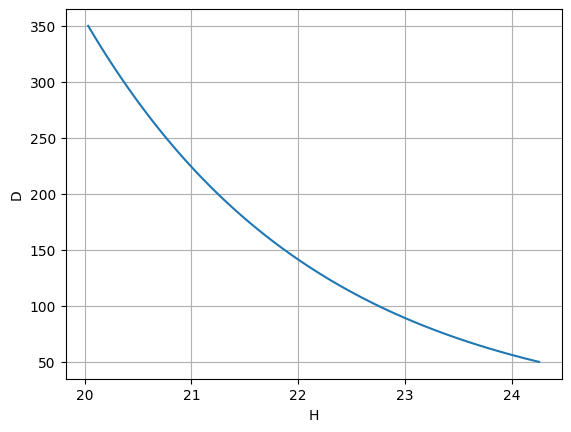

In [107]:
p = 0.14
D = np.linspace(50, 350, 100)
H = H_abs(p, D/1000)

plt.plot(H, D)
plt.xlabel("H")
plt.ylabel("D")
plt.grid()
plt.savefig("Absolute_Magnitud_Diameter.png")

### TEST USING 433 Eros, 774 Armor, 149 Medusa, 314 Rosalia

| Name        | Type | Date (1997)  | UT   | r*    | g*-r* | Vmea  | Vcat  | ΔV   |
|-------------|------|---------|------|-------|-------|--------|--------|------|
| 433 Eros    | S    | Sep 30  | 1226 | 13.30 | 0.67  | 13.57 | 13.09 | 0.48 |
| 774 Armor   | S    | Sep 28  | 0352 | 12.97 | 0.71  | 13.26 | 12.94 | 0.32 |
| 149 Medusa  | S    | Sep 29  | 0612 | 12.57 | 0.68  | 12.85 | 12.96 | 0.11 |
| 314 Rosalia | C    | Oct 5   | 0315 | 13.95 | 0.46  | 14.13 | 13.81 | 0.32 |


433 Eros

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '433'... 
Found: 433 Eros (A898 PA) 


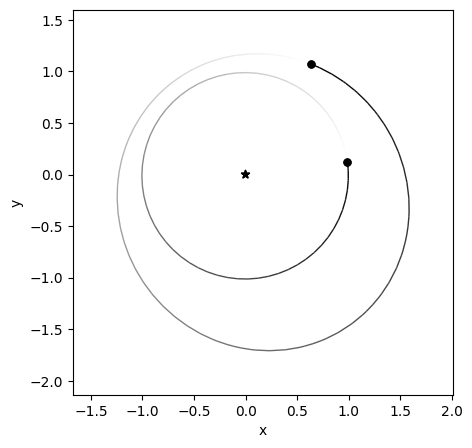

In [108]:
date = '1997-09-30'
diameter = 16.84  #km
p = 0.25

sim = rb.Simulation()
sim.units = 'AU', 's', 'kg'

sim.add("Sun", hash="sun", date=date)
sim.add("399", hash="earth", date=date)
sim.add("433", hash="eros", date=date)

fig = rb.OrbitPlot(sim)

In [109]:
r_eros = np.array(sim.particles['eros'].xyz)
r_earth = np.array(sim.particles['earth'].xyz)
r_earth_eros = r_eros - r_earth

alpha = np.arccos((r_eros @ r_earth_eros) / (mag(r_earth_eros) * mag(r_eros)))

H = H_abs(p, diameter)
print("Absolute Magnitude: ", H)

H_reducido = H_red(alpha, H)
print("Reduced Magnitude: ", H_reducido)

Delta = mag(r_eros)
r = mag(r_earth_eros)
mag_v = V(alpha, r, Delta, H)
print("Visual Magnitude: ", mag_v)


Absolute Magnitude:  10.99142387866291
Reduced Magnitude:  12.85317536116907
Visual Magnitude:  13.430570343180984


774 Armor

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '774'... 
Found: 774 Armor (A913 YE) 


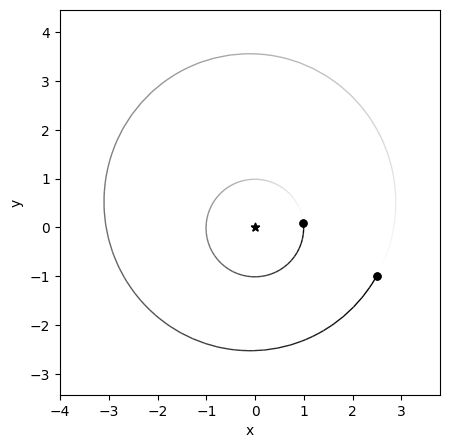

In [110]:
date = '1997-09-28'
diameter = 50.214  #km
p = 0.189

sim = rb.Simulation()
sim.units = 'AU', 's', 'kg'

sim.add("Sun", hash="sun", date=date)
sim.add("399", hash="earth", date=date)
sim.add("774", hash="armor", date=date)

fig = rb.OrbitPlot(sim)

In [111]:
r_armor = np.array(sim.particles['armor'].xyz)
r_earth = np.array(sim.particles['earth'].xyz)
r_earth_armor = r_armor - r_earth

alpha = np.arccos((r_armor @ r_earth_armor) / (mag(r_earth_armor) * mag(r_armor)))

H = H_abs(p, diameter)
print("Absolute Magnitude: ", H)

H_reducido = H_red(alpha, H)
print("Reduced Magnitude: ", H_reducido)

Delta = mag(r_armor)
r = mag(r_earth_armor)
mag_v = V(alpha, r, Delta, H)
print("Visual Magnitude: ", mag_v)

Absolute Magnitude:  8.92270573451706
Reduced Magnitude:  14.81475627802643
Visual Magnitude:  18.332347484952066


149 Medusa

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '149'... 
Found: 149 Medusa (A875 SA) 


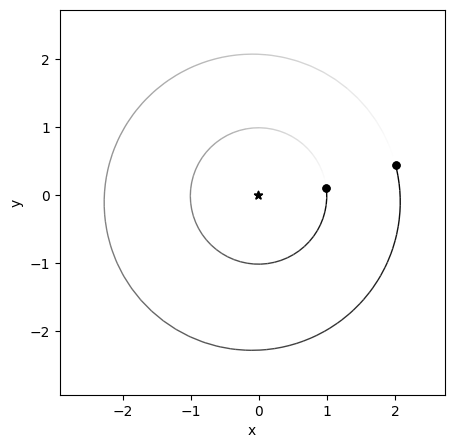

In [112]:
date = '1997-09-29'
diameter = 23.719  #km
p = 0.152

sim = rb.Simulation()
sim.units = 'AU', 's', 'kg'

sim.add("Sun", hash="sun", date=date)
sim.add("399", hash="earth", date=date)
sim.add("149", hash="medusa", date=date)

fig = rb.OrbitPlot(sim)

In [113]:
r_med = np.array(sim.particles['medusa'].xyz)
r_earth = np.array(sim.particles['earth'].xyz)
r_earth_med = r_med - r_earth

alpha = np.arccos((r_med @ r_earth_med) / (mag(r_earth_med) * mag(r_med)))
print('alpha: ', alpha/deg)

H = H_abs(p, diameter)
print("Absolute Magnitude: ", H)

H_reducido = H_red(alpha, H)
print("Reduced Magnitude: ", H_reducido)

Delta = mag(r_med)
r = mag(r_earth_med)
mag_v = V(alpha, r, Delta, H)
print("Visual Magnitude: ", mag_v)

alpha:  5.7153637382521705
Absolute Magnitude:  10.787893490822242
Reduced Magnitude:  nan
Visual Magnitude:  nan


314 Rosalia

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '314'... 
Found: 314 Rosalia (A891 RA) 


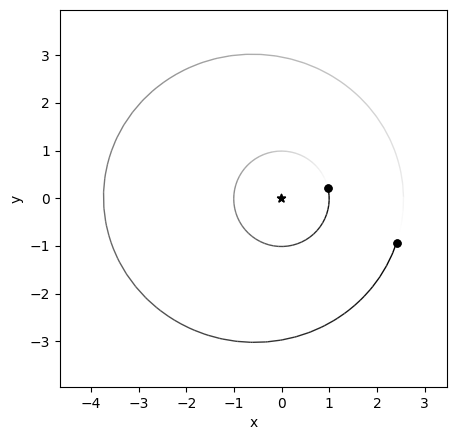

In [114]:
date = '1997-10-05'
diameter = 60.689  #km
p = 0.043

sim = rb.Simulation()
sim.units = 'AU', 's', 'kg'

sim.add("Sun", hash="sun", date=date)
sim.add("399", hash="earth", date=date)
sim.add("314", hash="rosalia", date=date)

fig = rb.OrbitPlot(sim)

In [115]:
r_ros = np.array(sim.particles['rosalia'].xyz)
r_earth = np.array(sim.particles['earth'].xyz)
r_earth_ros = r_ros - r_earth

alpha = np.arccos((r_ros @ r_earth_ros) / (mag(r_earth_ros) * mag(r_ros)))
print('alpha: ', alpha/deg)

H = H_abs(p, diameter)
print("Absolute Magnitude: ", H)

H_reducido = H_red(alpha, H)
print("Reduced Magnitude: ", H_reducido)

Delta = mag(r_ros)
r = mag(r_earth_ros)
mag_v = V(alpha, r, Delta, H)
print("Visual Magnitude: ", mag_v)

alpha:  17.314663557810945
Absolute Magnitude:  10.118763289794453
Reduced Magnitude:  11.729201102504511
Visual Magnitude:  15.117094208063245


## SIMULACION

Asumimos: G = 0.15, p = 0.14, D = 20 km

**Caso 1:** q = 0.5, w = 90°

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 


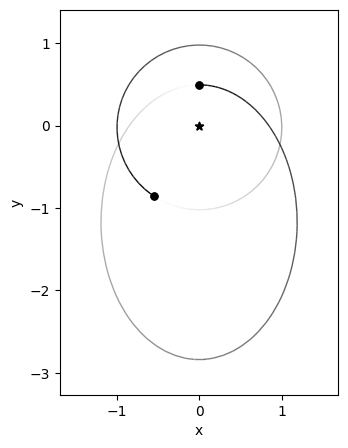

In [116]:
diameter = 1 #km
p = 0.14

q = 0.5
e = 0.7
inc = 0
Omega = 0
w = np.pi/2
a = q/(1-e)

sim = rb.Simulation()
sim.units = 'AU', 's', 'kg'
sim.integrator = "IAS15"
sim.dt = -86400

sim.add("Sun", hash="sun")
sim.add("399", hash="earth")
sim.add(a=a, e=e, inc=inc, Omega=Omega, omega=w, hash='Asteroid')

fig = rb.OrbitPlot(sim)

In [117]:
N = 100
year = 3.154e+7
times = np.linspace(0, year*4, N)

state_v = np.zeros((N, 6))
earth = np.zeros((N, 3))
for i, time in enumerate(times):
    sim.integrate(-time)
    sim.move_to_hel()
    state_v[i] = sim.particles["Asteroid"].xyz + sim.particles["Asteroid"].vxyz 
    earth[i] = sim.particles["earth"].xyz

In [118]:
H_absolute = np.zeros(N)
H_reducido = np.zeros(N)
mag_visual = np.zeros(N)

for i in range(N):

    r_asteroid = state_v[i][:3]
    r_earth = earth[i]
    r_earth_asteroid = r_asteroid - r_earth

    Delta = mag(r_earth_asteroid)
    r = mag(r_asteroid)

    alpha = np.arccos((r_asteroid @ r_earth_asteroid) / (Delta * r))

    H = H_abs(p, diameter)
    H_absolute[i] = H

    H_reducido[i] = H_red(alpha, H)
    mag_visual[i] = V(alpha, r, Delta, H)

In [119]:
t = times/year
r_asteroid = state_v[:,:3]
r_earth = earth
r_earth_asteroid = r_asteroid - r_earth

Delta = np.array([mag(posicion) for posicion in r_earth_asteroid])
r = np.array([mag(posicion) for posicion in r_asteroid])
alpha = [np.arccos((r_asteroid[p] @ r_earth_asteroid[p]) / (Delta[p] * r[p]))/deg for p in range(len(r_asteroid))]

x = r_asteroid[:,0]
y = r_asteroid[:,1]

xearth = r_earth[:,0]
yearth = r_earth[:,1]

titles = ['Angle', 'Orbits']
x_labels = ['Time (years)', 'x AU']
y_labels = ['α', 'y AU']

annotation_text = f"Parameters: q = {q}, w = {w/deg}, e = {e}, i = {inc}, a = {np.round(a, 2)}, Omega = {Omega}"

fig = make_subplots(rows=1, cols=2, subplot_titles=titles)

# Agregar trazas de línea
fig.add_trace(go.Scatter(x=t, y=alpha, mode='lines', name='α'), row=1, col=1)
fig.add_trace(go.Scatter(x=x, y=y, mode='lines', name='Asteroid'), row=1, col=2)
fig.add_trace(go.Scatter(x=xearth, y=yearth, mode='lines', name='Earth'), row=1, col=2)
fig.add_trace(go.Scatter(x=[0], y=[0], mode='markers', marker=dict(color='Yellow', size=10), name='Sun'), row=1, col=2)

# Etiquetas de ejes
fig.update_xaxes(title_text=x_labels[0], row=1, col=1)
fig.update_xaxes(title_text=x_labels[1], scaleanchor="x", scaleratio=1,row=1, col=2)

fig.update_yaxes(title_text=y_labels[0], row=1, col=1)
fig.update_yaxes(title_text=y_labels[1], scaleanchor="x", scaleratio=1, row=1, col=2)

# Agregar caja de texto (annotation)
fig.add_annotation(
    text=annotation_text,
    xref="paper", yref="paper",
    x=0.5, y=-0.3,
    showarrow=False,
    align='left',
    bordercolor="black",
    borderwidth=1,
    bgcolor="lightyellow",
    font=dict(size=12)
)

fig.update_layout(
    height=400,
    width=1150,
    title_text="Asteroid Phase Angle and Position Variation Over Background Integration Time"
)
fig.show()

In [120]:
x = times/year
y1 = H_absolute
y2 = H_reducido
y3 = mag_visual

titles = ['Absolute Magnitude', 'Reduced Magnitude', 'Visual Magnitude']
x_labels = ['Time (years)', 'Time (years)', 'Time (years)']
y_labels = ['H', 'H(α)', 'V']

annotation_text = f"Parameters: q = {q}, w = {w/deg}, e = {e}, i = {inc}, a = {np.round(a, 2)}, Omega = {Omega}"

fig = make_subplots(rows=1, cols=3, subplot_titles=titles)

# Agregar trazas de línea
fig.add_trace(go.Scatter(x=x, y=y1, mode='lines', name='H'), row=1, col=1)
fig.add_trace(go.Scatter(x=x, y=y2, mode='lines', name='H(α)'), row=1, col=2)
fig.add_trace(go.Scatter(x=x, y=y3, mode='lines', name='V'), row=1, col=3)

# Etiquetas de ejes
fig.update_xaxes(title_text=x_labels[0], row=1, col=1)
fig.update_xaxes(title_text=x_labels[1], row=1, col=2)
fig.update_xaxes(title_text=x_labels[2], row=1, col=3)

fig.update_yaxes(title_text=y_labels[0], row=1, col=1)
fig.update_yaxes(title_text=y_labels[1], row=1, col=2)
fig.update_yaxes(title_text=y_labels[2], row=1, col=3)

# Agregar caja de texto (annotation)
fig.add_annotation(
    text=annotation_text,
    xref="paper", yref="paper",
    x=0.5, y=-0.3,
    showarrow=False,
    align='left',
    bordercolor="black",
    borderwidth=1,
    bgcolor="lightyellow",
    font=dict(size=12)
)

fig.update_layout(
    height=400,
    width=1150,
    title_text="Asteroid Magnitud Variation Over Background Integration Time"
)

fig.show()


### Calculo de la Magnitud Absoluta Reducida usando la relacion:

H(α) = H (1−α/180)

In [121]:
H_absolute = np.zeros(N)
H_reducido = np.zeros(N)
mag_visual = np.zeros(N)

for i in range(N):

    r_asteroid = state_v[i][:3]
    r_earth = earth[i]
    r_earth_asteroid = r_asteroid - r_earth

    Delta = mag(r_earth_asteroid)
    r = mag(r_asteroid)

    alpha = np.arccos((r_asteroid @ r_earth_asteroid) / (Delta * r))

    H = H_abs(p, diameter)
    H_absolute[i] = H

    H_reducido[i] = H_red2(alpha/deg, H)
    mag_visual[i] = V2(alpha, r, Delta, H)

In [122]:
x = times/year
y1 = H_absolute
y2 = H_reducido
y3 = mag_visual

titles = ['Absolute Magnitude', 'Reduced Magnitude', 'Visual Magnitude']
x_labels = ['Time (years)', 'Time (years)', 'Time (years)']
y_labels = ['H', 'H(α)', 'V']

annotation_text = f"Parameters: q = {q}, w = {w/deg}, e = {e}, i = {i}, a = {np.round(a, 2)}, Omega = {Omega}"

fig = make_subplots(rows=1, cols=3, subplot_titles=titles)

# Agregar trazas de línea
fig.add_trace(go.Scatter(x=x, y=y1, mode='lines', name='H'), row=1, col=1)
fig.add_trace(go.Scatter(x=x, y=y2, mode='lines', name='H(α)'), row=1, col=2)
fig.add_trace(go.Scatter(x=x, y=y3, mode='lines', name='V'), row=1, col=3)
fig.add_hline(y=np.mean(y3), row=1, col=3)

# Etiquetas de ejes
fig.update_xaxes(title_text=x_labels[0], row=1, col=1)
fig.update_xaxes(title_text=x_labels[1], row=1, col=2)
fig.update_xaxes(title_text=x_labels[2], row=1, col=3)

fig.update_yaxes(title_text=y_labels[0], row=1, col=1)
fig.update_yaxes(title_text=y_labels[1], row=1, col=2)
fig.update_yaxes(title_text=y_labels[2], row=1, col=3)

# Agregar caja de texto (annotation)
fig.add_annotation(
    text=annotation_text,
    xref="paper", yref="paper",
    x=0.5, y=-0.3,
    showarrow=False,
    align='left',
    bordercolor="black",
    borderwidth=1,
    bgcolor="lightyellow",
    font=dict(size=12)
)

fig.update_layout(
    height=400,
    width=1150,
    title_text="Asteroid Magnitud Variation Over Background Integration Time"
)
print(np.mean(y3))
fig.show()


20.8904882979104


**Caso 2:** q = 0.5, w = 270°

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 


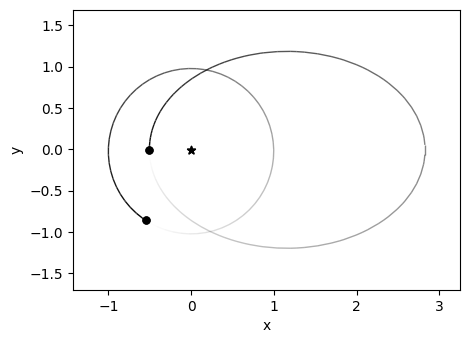

In [124]:
diameter = 1 #km
p = 0.14

q = 0.5
e = 0.7
inc = 0
Omega = 0
w = np.pi
a = q/(1-e)

sim = rb.Simulation()
sim.units = 'AU', 's', 'kg'
sim.integrator = "IAS15"
sim.dt = -86400

sim.add("Sun", hash="sun")
sim.add("399", hash="earth")
sim.add(a=a, e=e, inc=inc, omega=w, Omega=Omega, hash='Asteroid')

fig = rb.OrbitPlot(sim)

In [125]:
N = 100
year = 3.154e+7
times = np.linspace(0, year*4, N)

state_v = np.zeros((N, 6))
earth = np.zeros((N, 3))
for i,time in enumerate(times):
    sim.integrate(-time)
    sim.move_to_hel()
    state_v[i] = sim.particles["Asteroid"].xyz + sim.particles["Asteroid"].vxyz 
    earth[i] = sim.particles["earth"].xyz

In [126]:
H_absolute = np.zeros(N)
H_reducido = np.zeros(N)
mag_visual = np.zeros(N)

for i in range(N):

    r_asteroid = state_v[i][:3]
    r_earth = earth[i]
    r_earth_asteroid = r_asteroid - r_earth

    Delta = mag(r_earth_asteroid)
    r = mag(r_asteroid)

    alpha = np.arccos((r_asteroid @ r_earth_asteroid) / (Delta * r))

    H = H_abs(p, diameter)
    H_absolute[i] = H

    H_reducido[i] = H_red(alpha, H)
    mag_visual[i] = V(alpha, r, Delta, H)

In [127]:
t = times/year
r_asteroid = state_v[:,:3]
r_earth = earth
r_earth_asteroid = r_asteroid - r_earth

Delta = np.array([mag(posicion) for posicion in r_earth_asteroid])
r = np.array([mag(posicion) for posicion in r_asteroid])
alpha = [np.arccos((r_asteroid[p] @ r_earth_asteroid[p]) / (Delta[p] * r[p]))/deg for p in range(len(r_asteroid))]

x = r_asteroid[:,0]
y = r_asteroid[:,1]

xearth = r_earth[:,0]
yearth = r_earth[:,1]

titles = ['Angle', 'Orbits']
x_labels = ['Time (years)', 'x AU']
y_labels = ['α', 'y AU']

annotation_text = f"Parameters: q = {q}, w = {w/deg}, e = {e}, i = {inc}, a = {np.round(a, 2)}, Omega = {Omega}"

fig = make_subplots(rows=1, cols=2, subplot_titles=titles)

# Agregar trazas de línea
fig.add_trace(go.Scatter(x=t, y=alpha, mode='lines', name='α'), row=1, col=1)
fig.add_trace(go.Scatter(x=x, y=y, mode='lines', name='Asteroid'), row=1, col=2)
fig.add_trace(go.Scatter(x=xearth, y=yearth, mode='lines', name='Earth'), row=1, col=2)
fig.add_trace(go.Scatter(x=[0], y=[0], mode='markers', marker=dict(color='Yellow', size=10), name='Sun'), row=1, col=2)

# Etiquetas de ejes
fig.update_xaxes(title_text=x_labels[0], row=1, col=1)
fig.update_xaxes(title_text=x_labels[1], scaleanchor="x", scaleratio=1,row=1, col=2)

fig.update_yaxes(title_text=y_labels[0], row=1, col=1)
fig.update_yaxes(title_text=y_labels[1], scaleanchor="x", scaleratio=1, row=1, col=2)

# Agregar caja de texto (annotation)
fig.add_annotation(
    text=annotation_text,
    xref="paper", yref="paper",
    x=0.5, y=-0.3,
    showarrow=False,
    align='left',
    bordercolor="black",
    borderwidth=1,
    bgcolor="lightyellow",
    font=dict(size=12)
)

fig.update_layout(
    height=400,
    width=1150,
    title_text="Asteroid Phase Angle and Position Variation Over Background Integration Time"
)
fig.show()

In [128]:
x = times/year
y1 = H_absolute
y2 = H_reducido
y3 = mag_visual

titles = ['Absolute Magnitude', 'Reduced Magnitude', 'Visual Magnitude']
x_labels = ['Time (years)', 'Time (years)', 'Time (years)']
y_labels = ['H', 'H(α)', 'V']

annotation_text = f"Parameters: q = {q}, w = {w/deg}, e = {e}, i = {inc}, a = {np.round(a, 2)}, Omega = {Omega}"

fig = make_subplots(rows=1, cols=3, subplot_titles=titles)

# Agregar trazas de línea
fig.add_trace(go.Scatter(x=x, y=y1, mode='lines', name='H'), row=1, col=1)
fig.add_trace(go.Scatter(x=x, y=y2, mode='lines', name='H(α)'), row=1, col=2)
fig.add_trace(go.Scatter(x=x, y=y3, mode='lines', name='V'), row=1, col=3)

# Etiquetas de ejes
fig.update_xaxes(title_text=x_labels[0], row=1, col=1)
fig.update_xaxes(title_text=x_labels[1], row=1, col=2)
fig.update_xaxes(title_text=x_labels[2], row=1, col=3)

fig.update_yaxes(title_text=y_labels[0], row=1, col=1)
fig.update_yaxes(title_text=y_labels[1], row=1, col=2)
fig.update_yaxes(title_text=y_labels[2], row=1, col=3)

# Agregar caja de texto (annotation)
fig.add_annotation(
    text=annotation_text,
    xref="paper", yref="paper",
    x=0.5, y=-0.3,
    showarrow=False,
    align='left',
    bordercolor="black",
    borderwidth=1,
    bgcolor="lightyellow",
    font=dict(size=12)
)

fig.update_layout(
    height=400,
    width=1150,
    title_text="Asteroid Magnitud Variation Over Background Integration Time"
)

fig.show()

### Calculo de la Magnitud Absoluta Reducida usando la relacion:

H(α) = H (1−α/180)

In [129]:
H_absolute = np.zeros(N)
H_reducido = np.zeros(N)
mag_visual = np.zeros(N)

for i in range(N):

    r_asteroid = state_v[i][:3]
    r_earth = earth[i]
    r_earth_asteroid = r_asteroid - r_earth

    Delta = mag(r_earth_asteroid)
    r = mag(r_asteroid)

    alpha = np.arccos((r_asteroid @ r_earth_asteroid) / (Delta * r))

    H = H_abs(p, diameter)
    H_absolute[i] = H

    H_reducido[i] = H_red2(alpha/deg, H)
    mag_visual[i] = V2(alpha, r, Delta, H)

In [130]:
x = times/year
y1 = H_absolute
y2 = H_reducido
y3 = mag_visual

titles = ['Absolute Magnitude', 'Reduced Magnitude', 'Visual Magnitude']
x_labels = ['Time (years)', 'Time (years)', 'Time (years)']
y_labels = ['H', 'H(α)', 'V']

annotation_text = f"Parameters: q = {q}, w = {w/deg}, e = {e}, i = {inc}, a = {np.round(a, 2)}, Omega = {Omega}"

fig = make_subplots(rows=1, cols=3, subplot_titles=titles)

# Agregar trazas de línea
fig.add_trace(go.Scatter(x=x, y=y1, mode='lines', name='H'), row=1, col=1)
fig.add_trace(go.Scatter(x=x, y=y2, mode='lines', name='H(α)'), row=1, col=2)
fig.add_trace(go.Scatter(x=x, y=y3, mode='lines', name='V'), row=1, col=3)
fig.add_hline(y=np.mean(y3), row=1, col=3)

# Etiquetas de ejes
fig.update_xaxes(title_text=x_labels[0], row=1, col=1)
fig.update_xaxes(title_text=x_labels[1], row=1, col=2)
fig.update_xaxes(title_text=x_labels[2], row=1, col=3)

fig.update_yaxes(title_text=y_labels[0], row=1, col=1)
fig.update_yaxes(title_text=y_labels[1], row=1, col=2)
fig.update_yaxes(title_text=y_labels[2], row=1, col=3)

# Agregar caja de texto (annotation)
fig.add_annotation(
    text=annotation_text,
    xref="paper", yref="paper",
    x=0.5, y=-0.3,
    showarrow=False,
    align='left',
    bordercolor="black",
    borderwidth=1,
    bgcolor="lightyellow",
    font=dict(size=12)
)

fig.update_layout(
    height=400,
    width=1150,
    title_text="Asteroid Magnitud Variation Over Background Integration Time"
)
print(np.mean(y3))
fig.show()

20.478181060713904


**Caso 3:** q = 0.5, w = 270°

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 


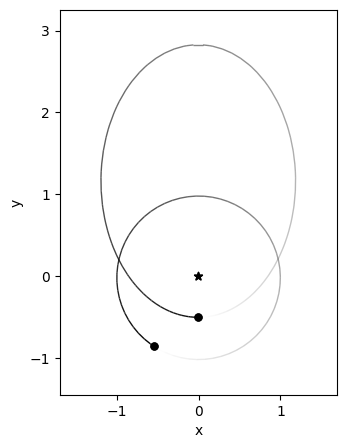

In [142]:
diameter = 1 #km
p = 0.14

q = 0.5
e = 0.7
inc = 0
Omega = 0
w = 3*np.pi/2
a = q/(1-e)

sim = rb.Simulation()
sim.units = 'AU', 's', 'kg'
sim.integrator = "IAS15"
sim.dt = -86400

sim.add("Sun", hash="sun")
sim.add("399", hash="earth")
sim.add(a=a, e=e, inc=inc, omega=w, Omega=Omega, hash='Asteroid')

fig = rb.OrbitPlot(sim)

In [143]:
N = 100
year = 3.154e+7
times = np.linspace(0, year*4, N)

state_v = np.zeros((N, 6))
earth = np.zeros((N, 3))
for i,time in enumerate(times):
    sim.integrate(-time)
    sim.move_to_hel()
    state_v[i] = sim.particles["Asteroid"].xyz + sim.particles["Asteroid"].vxyz 
    earth[i] = sim.particles["earth"].xyz

In [144]:
H_absolute = np.zeros(N)
H_reducido = np.zeros(N)
mag_visual = np.zeros(N)

for i in range(N):

    r_asteroid = state_v[i][:3]
    r_earth = earth[i]
    r_earth_asteroid = r_asteroid - r_earth

    Delta = mag(r_earth_asteroid)
    r = mag(r_asteroid)

    alpha = np.arccos((r_asteroid @ r_earth_asteroid) / (Delta * r))

    H = H_abs(p, diameter)
    H_absolute[i] = H

    H_reducido[i] = H_red(alpha, H)
    mag_visual[i] = V(alpha, r, Delta, H)

c:\Users\JuanitaTI\Documents\juanita\repo\TesisRepo\Utils.py:161: RuntimeWarning:

invalid value encountered in log10



In [145]:
t = times/year
r_asteroid = state_v[:,:3]
r_earth = earth
r_earth_asteroid = r_asteroid - r_earth

Delta = np.array([mag(posicion) for posicion in r_earth_asteroid])
r = np.array([mag(posicion) for posicion in r_asteroid])
alpha = [np.arccos((r_asteroid[p] @ r_earth_asteroid[p]) / (Delta[p] * r[p]))/deg for p in range(len(r_asteroid))]

x = r_asteroid[:,0]
y = r_asteroid[:,1]

xearth = r_earth[:,0]
yearth = r_earth[:,1]

titles = ['Angle', 'Orbits']
x_labels = ['Time (years)', 'x AU']
y_labels = ['α', 'y AU']

annotation_text = f"Parameters: q = {q}, w = {w/deg}, e = {e}, i = {inc}, a = {np.round(a, 2)}, Omega = {Omega}"

fig = make_subplots(rows=1, cols=2, subplot_titles=titles)

# Agregar trazas de línea
fig.add_trace(go.Scatter(x=t, y=alpha, mode='lines', name='α'), row=1, col=1)
fig.add_trace(go.Scatter(x=x, y=y, mode='lines', name='Asteroid'), row=1, col=2)
fig.add_trace(go.Scatter(x=xearth, y=yearth, mode='lines', name='Earth'), row=1, col=2)
fig.add_trace(go.Scatter(x=[0], y=[0], mode='markers', marker=dict(color='Yellow', size=10), name='Sun'), row=1, col=2)

# Etiquetas de ejes
fig.update_xaxes(title_text=x_labels[0], row=1, col=1)
fig.update_xaxes(title_text=x_labels[1], scaleanchor="x", scaleratio=1,row=1, col=2)

fig.update_yaxes(title_text=y_labels[0], row=1, col=1)
fig.update_yaxes(title_text=y_labels[1], scaleanchor="x", scaleratio=1, row=1, col=2)

# Agregar caja de texto (annotation)
fig.add_annotation(
    text=annotation_text,
    xref="paper", yref="paper",
    x=0.5, y=-0.3,
    showarrow=False,
    align='left',
    bordercolor="black",
    borderwidth=1,
    bgcolor="lightyellow",
    font=dict(size=12)
)

fig.update_layout(
    height=400,
    width=1150,
    title_text="Asteroid Phase Angle and Position Variation Over Background Integration Time"
)
fig.show()

In [146]:
x = times/year
y1 = H_absolute
y2 = H_reducido
y3 = mag_visual

titles = ['Absolute Magnitude', 'Reduced Magnitude', 'Visual Magnitude']
x_labels = ['Time (years)', 'Time (years)', 'Time (years)']
y_labels = ['H', 'H(α)', 'V']

annotation_text = f"Parameters: q = {q}, w = {w/deg}, e = {e}, i = {inc}, a = {np.round(a, 2)}, Omega = {Omega}"

fig = make_subplots(rows=1, cols=3, subplot_titles=titles)

# Agregar trazas de línea
fig.add_trace(go.Scatter(x=x, y=y1, mode='lines', name='H'), row=1, col=1)
fig.add_trace(go.Scatter(x=x, y=y2, mode='lines', name='H(α)'), row=1, col=2)
fig.add_trace(go.Scatter(x=x, y=y3, mode='lines', name='V'), row=1, col=3)

# Etiquetas de ejes
fig.update_xaxes(title_text=x_labels[0], row=1, col=1)
fig.update_xaxes(title_text=x_labels[1], row=1, col=2)
fig.update_xaxes(title_text=x_labels[2], row=1, col=3)

fig.update_yaxes(title_text=y_labels[0], row=1, col=1)
fig.update_yaxes(title_text=y_labels[1], row=1, col=2)
fig.update_yaxes(title_text=y_labels[2], row=1, col=3)

# Agregar caja de texto (annotation)
fig.add_annotation(
    text=annotation_text,
    xref="paper", yref="paper",
    x=0.5, y=-0.3,
    showarrow=False,
    align='left',
    bordercolor="black",
    borderwidth=1,
    bgcolor="lightyellow",
    font=dict(size=12)
)

fig.update_layout(
    height=400,
    width=1150,
    title_text="Asteroid Magnitud Variation Over Background Integration Time"
)

fig.show()

In [147]:
H_absolute = np.zeros(N)
H_reducido = np.zeros(N)
mag_visual = np.zeros(N)

for i in range(N):

    r_asteroid = state_v[i][:3]
    r_earth = earth[i]
    r_earth_asteroid = r_asteroid - r_earth

    Delta = mag(r_earth_asteroid)
    r = mag(r_asteroid)

    alpha = np.arccos((r_asteroid @ r_earth_asteroid) / (Delta * r))

    H = H_abs(p, diameter)
    H_absolute[i] = H

    H_reducido[i] = H_red2(alpha/deg, H)
    mag_visual[i] = V2(alpha, r, Delta, H)

In [148]:
x = times/year
y1 = H_absolute
y2 = H_reducido
y3 = mag_visual

titles = ['Absolute Magnitude', 'Reduced Magnitude', 'Visual Magnitude']
x_labels = ['Time (years)', 'Time (years)', 'Time (years)']
y_labels = ['H', 'H(α)', 'V']

annotation_text = f"Parameters: q = {q}, w = {w/deg}, e = {e}, i = {inc}, a = {np.round(a, 2)}, Omega = {Omega}"

fig = make_subplots(rows=1, cols=3, subplot_titles=titles)

# Agregar trazas de línea
fig.add_trace(go.Scatter(x=x, y=y1, mode='lines', name='H'), row=1, col=1)
fig.add_trace(go.Scatter(x=x, y=y2, mode='lines', name='H(α)'), row=1, col=2)
fig.add_trace(go.Scatter(x=x, y=y3, mode='lines', name='V'), row=1, col=3)
fig.add_hline(y=np.mean(y3), row=1, col=3)

# Etiquetas de ejes
fig.update_xaxes(title_text=x_labels[0], row=1, col=1)
fig.update_xaxes(title_text=x_labels[1], row=1, col=2)
fig.update_xaxes(title_text=x_labels[2], row=1, col=3)

fig.update_yaxes(title_text=y_labels[0], row=1, col=1)
fig.update_yaxes(title_text=y_labels[1], row=1, col=2)
fig.update_yaxes(title_text=y_labels[2], row=1, col=3)

# Agregar caja de texto (annotation)
fig.add_annotation(
    text=annotation_text,
    xref="paper", yref="paper",
    x=0.5, y=-0.3,
    showarrow=False,
    align='left',
    bordercolor="black",
    borderwidth=1,
    bgcolor="lightyellow",
    font=dict(size=12)
)

fig.update_layout(
    height=400,
    width=1150,
    title_text="Asteroid Magnitud Variation Over Background Integration Time"
)
print(np.mean(y3))
fig.show()

20.648626919257858


**Caso 4:** q = 1, w = 270°

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 


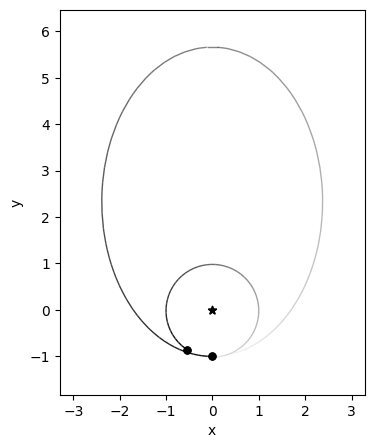

In [154]:
diameter = 1 #km
p = 0.14

q = 1
e = 0.7
inc = 0
Omega = 0
w = 3*np.pi/2
a = q/(1-e)

sim = rb.Simulation()
sim.units = 'AU', 's', 'kg'
sim.integrator = "IAS15"
sim.dt = -86400

sim.add("Sun", hash="sun")
sim.add("399", hash="earth")
sim.add(a=a, e=e, inc=inc, omega=w, Omega=Omega, hash='Asteroid')

fig = rb.OrbitPlot(sim)

In [155]:
N = 100
year = 3.154e+7
times = np.linspace(0, year*8, N)

state_v = np.zeros((N, 6))
earth = np.zeros((N, 3))
for i,time in enumerate(times):
    sim.integrate(-time)
    sim.move_to_hel()
    state_v[i] = sim.particles["Asteroid"].xyz + sim.particles["Asteroid"].vxyz 
    earth[i] = sim.particles["earth"].xyz

In [156]:
H_absolute = np.zeros(N)
H_reducido = np.zeros(N)
mag_visual = np.zeros(N)

for i in range(N):

    r_asteroid = state_v[i][:3]
    r_earth = earth[i]
    r_earth_asteroid = r_asteroid - r_earth

    Delta = mag(r_earth_asteroid)
    r = mag(r_asteroid)

    alpha = np.arccos((r_asteroid @ r_earth_asteroid) / (Delta * r))

    H = H_abs(p, diameter)
    H_absolute[i] = H

    H_reducido[i] = H_red(alpha, H)
    mag_visual[i] = V(alpha, r, Delta, H)

In [157]:
t = times/year
r_asteroid = state_v[:,:3]
r_earth = earth
r_earth_asteroid = r_asteroid - r_earth

Delta = np.array([mag(posicion) for posicion in r_earth_asteroid])
r = np.array([mag(posicion) for posicion in r_asteroid])
alpha = [np.arccos((r_asteroid[p] @ r_earth_asteroid[p]) / (Delta[p] * r[p]))/deg for p in range(len(r_asteroid))]

x = r_asteroid[:,0]
y = r_asteroid[:,1]

xearth = r_earth[:,0]
yearth = r_earth[:,1]

titles = ['Angle', 'Orbits']
x_labels = ['Time (years)', 'x AU']
y_labels = ['α', 'y AU']

annotation_text = f"Parameters: q = {q}, w = {w/deg}, e = {e}, i = {inc}, a = {np.round(a, 2)}, Omega = {Omega}"

fig = make_subplots(rows=1, cols=2, subplot_titles=titles)

# Agregar trazas de línea
fig.add_trace(go.Scatter(x=t, y=alpha, mode='lines', name='α'), row=1, col=1)
fig.add_trace(go.Scatter(x=x, y=y, mode='lines', name='Asteroid'), row=1, col=2)
fig.add_trace(go.Scatter(x=xearth, y=yearth, mode='lines', name='Earth'), row=1, col=2)
fig.add_trace(go.Scatter(x=[0], y=[0], mode='markers', marker=dict(color='Yellow', size=10), name='Sun'), row=1, col=2)

# Etiquetas de ejes
fig.update_xaxes(title_text=x_labels[0], row=1, col=1)
fig.update_xaxes(title_text=x_labels[1], scaleanchor="x", scaleratio=1,row=1, col=2)

fig.update_yaxes(title_text=y_labels[0], row=1, col=1)
fig.update_yaxes(title_text=y_labels[1], scaleanchor="x", scaleratio=1, row=1, col=2)

# Agregar caja de texto (annotation)
fig.add_annotation(
    text=annotation_text,
    xref="paper", yref="paper",
    x=0.5, y=-0.3,
    showarrow=False,
    align='left',
    bordercolor="black",
    borderwidth=1,
    bgcolor="lightyellow",
    font=dict(size=12)
)

fig.update_layout(
    height=400,
    width=1150,
    title_text="Asteroid Phase Angle and Position Variation Over Background Integration Time"
)
fig.show()

In [158]:
x = times/year
y1 = H_absolute
y2 = H_reducido
y3 = mag_visual

titles = ['Absolute Magnitude', 'Reduced Magnitude', 'Visual Magnitude']
x_labels = ['Time (years)', 'Time (years)', 'Time (years)']
y_labels = ['H', 'H(α)', 'V']

annotation_text = f"Parameters: q = {q}, w = {w/deg}, e = {e}, i = {inc}, a = {np.round(a, 2)}, Omega = {Omega}"

fig = make_subplots(rows=1, cols=3, subplot_titles=titles)

# Agregar trazas de línea
fig.add_trace(go.Scatter(x=x, y=y1, mode='lines', name='H'), row=1, col=1)
fig.add_trace(go.Scatter(x=x, y=y2, mode='lines', name='H(α)'), row=1, col=2)
fig.add_trace(go.Scatter(x=x, y=y3, mode='lines', name='V'), row=1, col=3)

# Etiquetas de ejes
fig.update_xaxes(title_text=x_labels[0], row=1, col=1)
fig.update_xaxes(title_text=x_labels[1], row=1, col=2)
fig.update_xaxes(title_text=x_labels[2], row=1, col=3)

fig.update_yaxes(title_text=y_labels[0], row=1, col=1)
fig.update_yaxes(title_text=y_labels[1], row=1, col=2)
fig.update_yaxes(title_text=y_labels[2], row=1, col=3)

# Agregar caja de texto (annotation)
fig.add_annotation(
    text=annotation_text,
    xref="paper", yref="paper",
    x=0.5, y=-0.3,
    showarrow=False,
    align='left',
    bordercolor="black",
    borderwidth=1,
    bgcolor="lightyellow",
    font=dict(size=12)
)

fig.update_layout(
    height=400,
    width=1150,
    title_text="Asteroid Magnitud Variation Over Background Integration Time"
)

fig.show()

In [159]:
H_absolute = np.zeros(N)
H_reducido = np.zeros(N)
mag_visual = np.zeros(N)

for i in range(N):

    r_asteroid = state_v[i][:3]
    r_earth = earth[i]
    r_earth_asteroid = r_asteroid - r_earth

    Delta = mag(r_earth_asteroid)
    r = mag(r_asteroid)

    alpha = np.arccos((r_asteroid @ r_earth_asteroid) / (Delta * r))

    H = H_abs(p, diameter)
    H_absolute[i] = H

    H_reducido[i] = H_red2(alpha/deg, H)
    mag_visual[i] = V2(alpha, r, Delta, H)

In [160]:
x = times/year
y1 = H_absolute
y2 = H_reducido
y3 = mag_visual

titles = ['Absolute Magnitude', 'Reduced Magnitude', 'Visual Magnitude']
x_labels = ['Time (years)', 'Time (years)', 'Time (years)']
y_labels = ['H', 'H(α)', 'V']

annotation_text = f"Parameters: q = {q}, w = {w/deg}, e = {e}, i = {inc}, a = {np.round(a, 2)}, Omega = {Omega}"

fig = make_subplots(rows=1, cols=3, subplot_titles=titles)

# Agregar trazas de línea
fig.add_trace(go.Scatter(x=x, y=y1, mode='lines', name='H'), row=1, col=1)
fig.add_trace(go.Scatter(x=x, y=y2, mode='lines', name='H(α)'), row=1, col=2)
fig.add_trace(go.Scatter(x=x, y=y3, mode='lines', name='V'), row=1, col=3)
fig.add_hline(y=np.mean(y3), row=1, col=3)

# Etiquetas de ejes
fig.update_xaxes(title_text=x_labels[0], row=1, col=1)
fig.update_xaxes(title_text=x_labels[1], row=1, col=2)
fig.update_xaxes(title_text=x_labels[2], row=1, col=3)

fig.update_yaxes(title_text=y_labels[0], row=1, col=1)
fig.update_yaxes(title_text=y_labels[1], row=1, col=2)
fig.update_yaxes(title_text=y_labels[2], row=1, col=3)

# Agregar caja de texto (annotation)
fig.add_annotation(
    text=annotation_text,
    xref="paper", yref="paper",
    x=0.5, y=-0.3,
    showarrow=False,
    align='left',
    bordercolor="black",
    borderwidth=1,
    bgcolor="lightyellow",
    font=dict(size=12)
)

fig.update_layout(
    height=400,
    width=1150,
    title_text="Asteroid Magnitud Variation Over Background Integration Time"
)
print(np.mean(y3))
fig.show()

23.251246371106323
